In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats
import numpy as np

In [71]:
#EDA
#chargement des donnees
data = pd.read_csv('ab_data.csv')
print("appercu des donnees :")
data.head()

appercu des donnees :


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [72]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


In [73]:
print("statistiques descriptives :")
data.describe()

statistiques descriptives :


,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [74]:
#valeurs manquantes 
print("valeurs manquantes :")
print(data.isnull().sum())

valeurs manquantes :
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64


In [75]:
#distribution des groupes
print("distribution des groupes :")
print(data['group'].value_counts())

print("distribution page d'acceuil :")
print(data['landing_page'].value_counts())

print("distribution des conversions :")
print(data['converted'].value_counts())

distribution des groupes :
group
treatment    147276
control      147202
Name: count, dtype: int64
distribution page d'acceuil :
landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64
distribution des conversions :
converted
0    259241
1     35237
Name: count, dtype: int64


In [76]:
#on observe que timestamp n'est pas du bon type, on vas donc le convertire en datetim
#anomalie detecter au niveau de group/landing_page, il y'a des utilisateurs qui ont ete mal assigner, on vas donc y remedier !

#conversion de timestamp en datetime
data['timestamp']=pd.to_datetime(data['timestamp'])

#correction des anomalies
anomalies = data[((data['group']=='control') & (data['landing_page']=='new_page')) | 
                 ((data['group']=='treatment') & (data['landing_page']=='old_page'))]
print(f"nombre d'anomalies : {len(anomalies)}")
print(anomalies.head())

nombre d'anomalies : 3893
     user_id                  timestamp      group landing_page  converted
22    767017 2017-01-12 22:58:14.991443    control     new_page          0
240   733976 2017-01-11 15:11:16.407599    control     new_page          0
308   857184 2017-01-20 07:34:59.832626  treatment     old_page          0
327   686623 2017-01-09 14:26:40.734775  treatment     old_page          0
357   856078 2017-01-12 12:29:30.354835  treatment     old_page          0


In [77]:
#on vas retirer les anomalie est garder que les utilisateur correctement assigner 
donnees_propres = data[((data['group']=='control') & (data['landing_page']=='old_page')) | 
                 ((data['group']=='treatment') & (data['landing_page']=='new_page'))]
print(f"dataset original : {len(data)}")
print(f"dataset propre : {len(donnees_propres)}")
print(f"anomalies retirer : {len(data)-len(donnees_propres)}")

dataset original : 294478
dataset propre : 290585
anomalies retirer : 3893


In [78]:
#on passe maintenant au calculs des metriques pour chaque groupe

#taux de conversion par groupe
taux_conversion = donnees_propres.groupby('group')['converted'].mean() * 100

print("taux de conversion par groupe :")
print (taux_conversion.round(2))

taux de conversion par groupe :
group
control      12.04
treatment    11.88
Name: converted, dtype: float64


In [79]:
#metrique complete par groupe
metriques = donnees_propres.groupby('group')['converted'].agg([
    ('total_utilisateurs', 'count'),
    ('total_conversions','sum'),
    ('taux_conversion', 'mean')
]
)
metriques['taux_conversion']= (metriques['taux_conversion'] * 100).round(2)
print('metriques par groupes :')
print(metriques)

metriques par groupes :
           total_utilisateurs  total_conversions  taux_conversion
group                                                            
control                145274              17489            12.04
treatment              145311              17264            11.88


In [80]:
taux_control = metriques.loc['control', 'taux_conversion']
taux_treatment = metriques.loc['treatment', 'taux_conversion']
difference = taux_treatment - taux_control

print(f"taux de conversion control : {taux_control}%")
print(f"taux de conversion treatment : {taux_treatment}%")
print(f"différence : {difference :.2f}%")

if difference > 0:
    print(f"\n la NEW PAGE a un taux de conversion plus élevé de {difference:.2f}%")
else:
    print(f"\n la OLD PAGE a un taux de conversion plus élevé de {abs(difference):.2f}%")

taux de conversion control : 12.04%
taux de conversion treatment : 11.88%
différence : -0.16%

 la OLD PAGE a un taux de conversion plus élevé de 0.16%


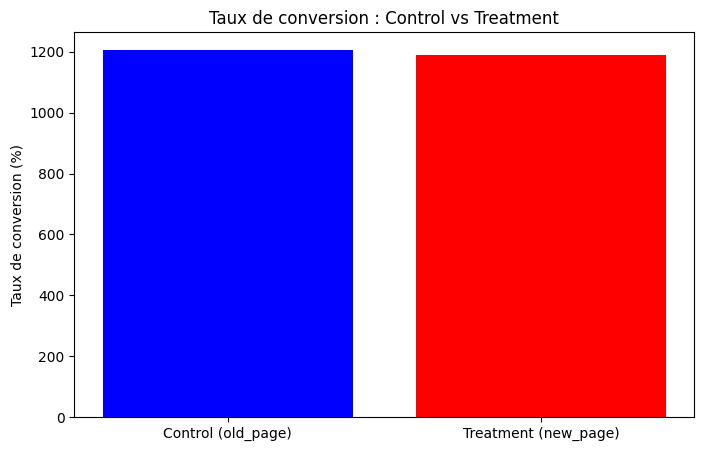

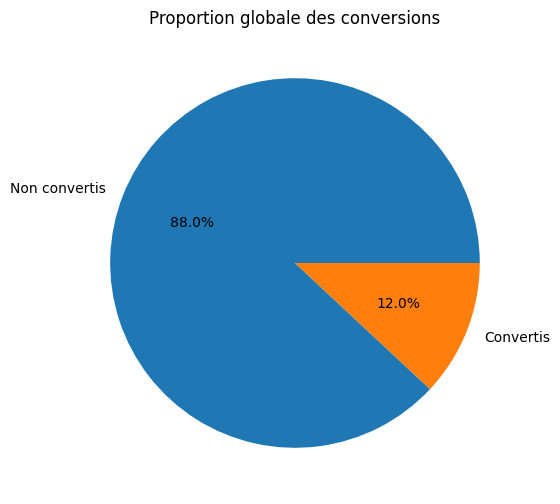

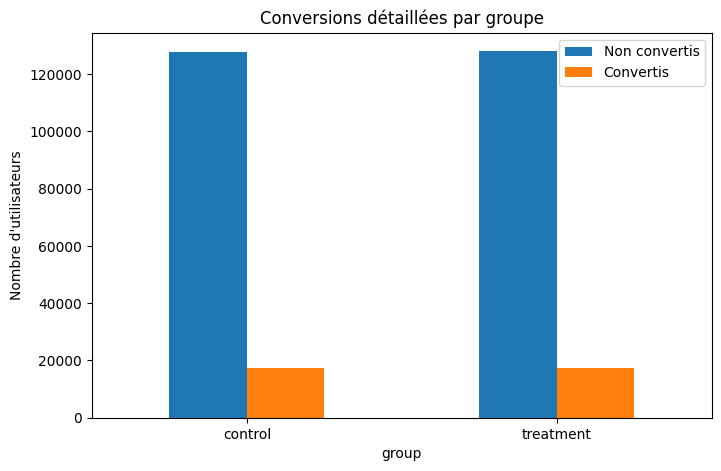

In [81]:
#on vas maintenant visualiser tout ça

#barchart du taux de conversion par groupe
# Données
taux_control   = metriques.loc['control', 'taux_conversion'] * 100
taux_treatment = metriques.loc['treatment', 'taux_conversion'] * 100

groupes = ['Control (old_page)', 'Treatment (new_page)']
taux    = [taux_control, taux_treatment]

# Graphique
plt.figure(figsize=(8, 5))
plt.bar(groupes, taux, color=['blue', 'red'])
plt.title('Taux de conversion : Control vs Treatment')
plt.ylabel('Taux de conversion (%)')
plt.show()

#Pie chart : proportion globale des conversion
valeurs = donnees_propres['converted'].value_counts()
labels  = ['Non convertis', 'Convertis']

plt.figure(figsize=(6, 6))
plt.pie(valeurs, labels=labels, autopct='%1.1f%%')
plt.title('Proportion globale des conversions')
plt.show()


#Bar chart groupé : conversions détaillées
conv_par_groupe = donnees_propres.groupby(['group', 'converted']).size().unstack()
conv_par_groupe.columns = ['Non convertis', 'Convertis']

conv_par_groupe.plot(kind='bar', figsize=(8, 5))
plt.title('Conversions détaillées par groupe')
plt.ylabel("Nombre d'utilisateurs")
plt.xticks(rotation=0)
plt.show()

In [82]:
#difference quasi invisible entre les deux groupes, on vas donc faire un test statistique 

In [83]:
#Z-test de proportions


nb_control   = metriques.loc['control', 'total_utilisateurs']
nb_treatment = metriques.loc['treatment', 'total_utilisateurs']

conv_control   = metriques.loc['control', 'total_conversions']
conv_treatment = metriques.loc['treatment', 'total_conversions']

print(" Données pour le test :")
print(f"Control   : {conv_control} conversions sur {nb_control} utilisateurs")
print(f"Treatment : {conv_treatment} conversions sur {nb_treatment} utilisateurs")

from statsmodels.stats.proportion import proportions_ztest

# Les données du test
conversions = [conv_control, conv_treatment]
observations = [nb_control, nb_treatment]

# Le test
stat, p_value = proportions_ztest(conversions, observations)

print(" Résultats du test Z: ")
print(f"Statistique Z : {stat:.4f}")
print(f"P-value       : {p_value:.4f}")


alpha = 0.05
print(" Décision ")
print(f"P-value : {p_value:.4f}")
print(f"Alpha   : {alpha}")
print()

if p_value < alpha:
    print(" On REJETTE H0")
    print(" Une des deux pages est vraiment meilleure")
else:
    print(" On NE REJETTE PAS H0")
    print(" La différence observée est probablement due au hasard")

 Données pour le test :
Control   : 17489 conversions sur 145274 utilisateurs
Treatment : 17264 conversions sur 145311 utilisateurs
 Résultats du test Z: 
Statistique Z : 1.3116
P-value       : 0.1897
 Décision 
P-value : 0.1897
Alpha   : 0.05

 On NE REJETTE PAS H0
 La différence observée est probablement due au hasard


In [84]:
                          #RAPPORT FINAL
                          
           #DONNÉES ANALYSÉES
# Dataset original    : 294 478 utilisateurs
# Anomalies supprimées: 3 893
# Dataset final       : 290 585

            #MÉTRIQUES CLÉS
# taux de conversion_control (old_page) : 12.04%
# taux de conversion_treatment (new_page) : 11.88%
# difference observé : 0.16%

            #TEST STATISTIQUE
# Test utilisé : Z-test de proportion
# P-value : 0.1897
# Alpha : 0.05
# Resultat : H0  non rejeter

            #CONCLUSION
# La difference de 0.16 entre old_page et new_page n'est pas statistiquement significative
    # On ne peut donc pas conclure qu'une pas est meilleur

            #RECOMMANDATIONS
# Ne pas déployer la new_page — pas de gain prouvé
# Revoir le design de la new_page plus radicalement
# Collecter plus de données sur une période plus longue
# Investiguer le taux global de 88% de non-conversion